# Benchmark model performance

This notebooks benchmarks the available predictive models on sequence data.

In [1]:
import collections
import itertools
import os

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from Bio.SeqUtils import IUPACData
from nettcr.models import NetTCR
from scipy import stats
from sklearn import metrics

from tcr_antigen_prediction.models import TCRStructMap

In [2]:
with h5py.File('data/processed/sequences.h5') as fh:
    cdr1_alphas = fh['cdr1_alpha'][:]
    cdr2_alphas = fh['cdr2_alpha'][:]
    cdr3_alphas = fh['cdr3_alpha'][:]
    cdr1_betas = fh['cdr1_beta'][:]
    cdr2_betas = fh['cdr2_beta'][:]
    cdr3_betas = fh['cdr3_beta'][:]
    peptides = fh['peptide'][:]
    mhcs = fh['mhc_pseudo'][:]

    folds = fh['fold'][:]
    labels = fh['label'][:]

In [3]:
predictions = []

for fold_num in range(1, 5 + 1):
    print('Fold:', fold_num)
    hold_out_indicies = np.where(folds == fold_num)[0]

    for model_path in 'models/TCRStructMap', 'models/TCRStructMap_sequence_only':
        print('Loading model:', model_path)
        model = TCRStructMap()
        model.load_state_dict(
            torch.load(
                os.path.join(model_path, f'model_{fold_num}.pt'),
                map_location=torch.device('cpu'),
                weights_only=True,
            )
        )

        print('Making predictions')
        model.eval()

        prediction = model(
            torch.tensor(cdr1_alphas[hold_out_indicies], dtype=torch.float32),
            torch.tensor(cdr2_alphas[hold_out_indicies], dtype=torch.float32),
            torch.tensor(cdr3_alphas[hold_out_indicies], dtype=torch.float32),
            torch.tensor(cdr1_betas[hold_out_indicies], dtype=torch.float32),
            torch.tensor(cdr2_betas[hold_out_indicies], dtype=torch.float32),
            torch.tensor(cdr3_betas[hold_out_indicies], dtype=torch.float32),
            torch.tensor(peptides[hold_out_indicies], dtype=torch.float32),
            torch.tensor(mhcs[hold_out_indicies], dtype=torch.float32),
        )

        model_name = os.path.basename(model_path)

        predictions.append(
            pd.DataFrame(
                {
                    'index': hold_out_indicies,
                    'fold': [fold_num for _ in range(len(hold_out_indicies))],
                    'model_name': [model_name for _ in range(len(hold_out_indicies))],
                    'label': labels[hold_out_indicies],
                    'prediction': prediction.squeeze(-1).detach().cpu().numpy(),
                }
            )
        )

predictions = pd.concat(predictions)

Fold: 1
Loading model: models/TCRStructMap
Making predictions
Loading model: models/TCRStructMap_sequence_only
Making predictions
Fold: 2
Loading model: models/TCRStructMap
Making predictions
Loading model: models/TCRStructMap_sequence_only
Making predictions
Fold: 3
Loading model: models/TCRStructMap
Making predictions
Loading model: models/TCRStructMap_sequence_only
Making predictions
Fold: 4
Loading model: models/TCRStructMap
Making predictions
Loading model: models/TCRStructMap_sequence_only
Making predictions
Fold: 5
Loading model: models/TCRStructMap
Making predictions
Loading model: models/TCRStructMap_sequence_only
Making predictions


In [4]:
with h5py.File('data/processed/sequences_right_pad_blosum.h5') as fh:
    cdr1_alphas_nettcr = fh['cdr1_alpha'][:]
    cdr2_alphas_nettcr = fh['cdr2_alpha'][:]
    cdr3_alphas_nettcr = fh['cdr3_alpha'][:]
    cdr1_betas_nettcr = fh['cdr1_beta'][:]
    cdr2_betas_nettcr = fh['cdr2_beta'][:]
    cdr3_betas_nettcr = fh['cdr3_beta'][:]
    peptides_nettcr = fh['peptide'][:]

    folds_nettcr = fh['fold'][:]
    labels_nettcr = fh['label'][:]

In [5]:
predictions_nettcr = []

for fold_num in range(1, 5 + 1):
    print('Fold:', fold_num)
    hold_out_indicies = np.where(folds_nettcr == fold_num)[0]

    model = NetTCR()
    model.load_state_dict(
        torch.load(
            os.path.join('models/NetTCR', f'model_{fold_num}.pt'),
            map_location=torch.device('cpu'),
            weights_only=True,
        )
    )

    print('Making predictions')
    model.eval()

    prediction = model(
        torch.tensor(cdr1_alphas_nettcr[hold_out_indicies], dtype=torch.float32),
        torch.tensor(cdr2_alphas_nettcr[hold_out_indicies], dtype=torch.float32),
        torch.tensor(cdr3_alphas_nettcr[hold_out_indicies], dtype=torch.float32),
        torch.tensor(cdr1_betas_nettcr[hold_out_indicies], dtype=torch.float32),
        torch.tensor(cdr2_betas_nettcr[hold_out_indicies], dtype=torch.float32),
        torch.tensor(cdr3_betas_nettcr[hold_out_indicies], dtype=torch.float32),
        torch.tensor(peptides_nettcr[hold_out_indicies], dtype=torch.float32),
    )

    predictions_nettcr.append(
        pd.DataFrame(
            {
                'index': hold_out_indicies,
                'fold': [fold_num for _ in range(len(hold_out_indicies))],
                'model_name': ['NetTCR' for _ in range(len(hold_out_indicies))],
                'label': labels_nettcr[hold_out_indicies],
                'prediction': prediction.squeeze(-1).detach().cpu().numpy(),
            }
        )
    )

predictions_nettcr = pd.concat(predictions_nettcr)

Fold: 1
Making predictions
Fold: 2
Making predictions
Fold: 3
Making predictions
Fold: 4
Making predictions
Fold: 5
Making predictions


In [6]:
predictions = pd.concat([predictions, predictions_nettcr])

In [ ]:
def model_name_sort_key(name: str) -> tuple[str, str]:
    return (-ord(name[0]), name)

## ROC

In [8]:
roc_results = predictions.groupby(['model_name', 'fold']).apply(
    lambda group: metrics.roc_curve(group['label'], group['prediction']),
    include_groups=False,
)
roc_results.name = 'roc_curve'
roc_results = roc_results.reset_index()

In [9]:
roc_results[['fpr', 'tpr', 'threshold']] = roc_results['roc_curve'].apply(pd.Series)

In [ ]:
roc_results['roc_auc'] = roc_results.apply(lambda row: metrics.auc(row['fpr'], row['tpr']), axis=1)

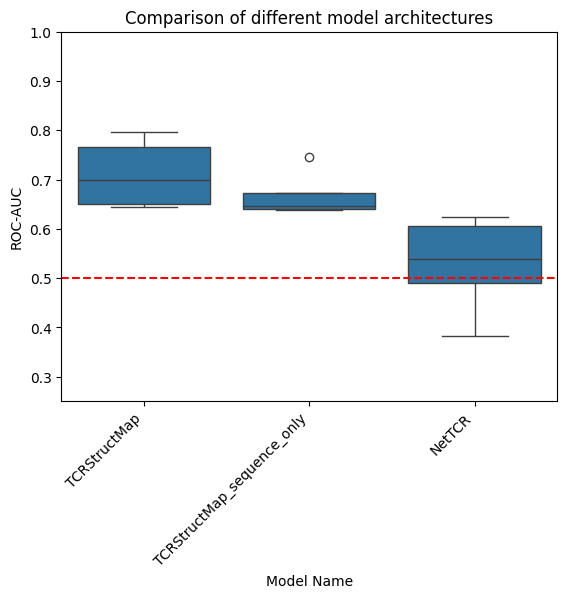

,mean,median,std
model_name,,,
TCRStructMap,0.711459,0.699872,0.068328
TCRStructMap_sequence_only,0.668781,0.645400,0.045501
NetTCR,0.528512,0.539377,0.097343


In [11]:
plt.title('Comparison of different model architectures')

sns.boxplot(
    roc_results,
    x='model_name',
    y='roc_auc',
    order=sorted(roc_results['model_name'].unique(), key=model_name_sort_key),
)
plt.axhline(0.5, color='r', linestyle='dashed')

plt.ylabel('ROC-AUC')
plt.xlabel('Model Name')
plt.xticks(rotation=45, ha='right')
plt.ylim([0.25, 1.0])
plt.show()

roc_results_agg = roc_results.groupby('model_name')['roc_auc'].agg(['mean', 'median', 'std'])
roc_results_agg = roc_results_agg.loc[sorted(roc_results_agg.index, key=model_name_sort_key)]

roc_results_agg

In [12]:
groups = list(roc_results.groupby('model_name')['roc_auc'])
groups = sorted(groups, key=lambda group: model_name_sort_key(group[0]))

print(stats.kruskal(*[group for _, group in groups]))

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.ranksums(group1, group2)

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

KruskalResult(statistic=10.220000000000006, pvalue=0.006036082923599548)


,group1,group2,stat,p_val,signficant
0,TCRStructMap,TCRStructMap_sequence_only,1.357806,0.174525,False
1,TCRStructMap,NetTCR,2.611165,0.009023,True
2,TCRStructMap_sequence_only,NetTCR,2.611165,0.009023,True


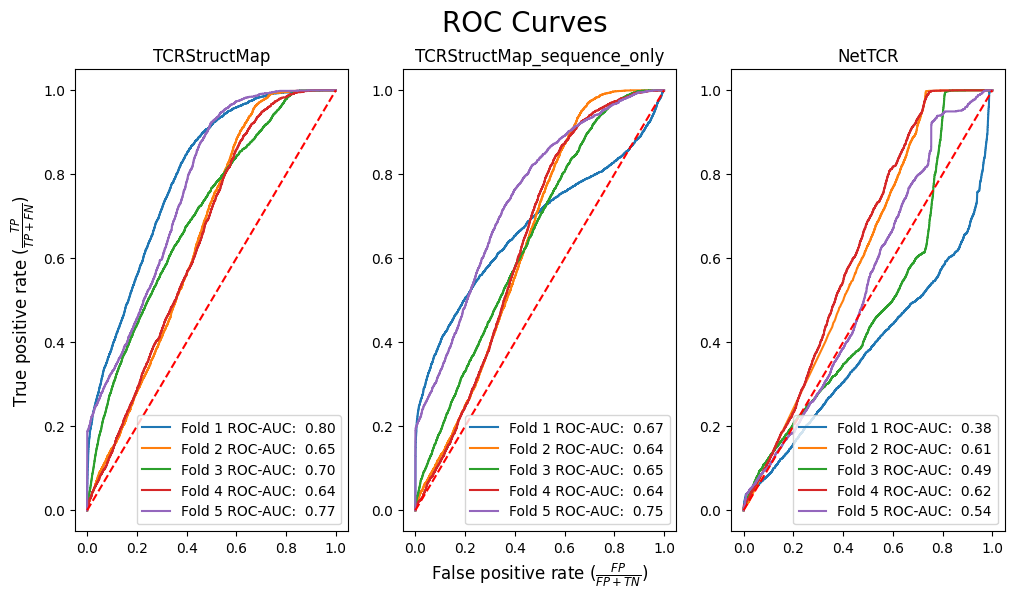

In [13]:
model_groups = roc_results.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=lambda name: (-ord(name[0]), name, len(name)))

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('ROC Curves', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        roc_auc = fold_group['roc_auc'].to_numpy()[0]
        group = fold_group.explode(['tpr', 'fpr'])

        axes[i].plot(group['fpr'], group['tpr'], label=f'Fold {fold} ROC-AUC: {roc_auc: .2f}')

    if i == 0:
        axes[i].set_ylabel(r'True positive rate ($\frac{TP}{TP + FN}$)', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel(r'False positive rate ($\frac{FP}{FP + TN}$)', fontsize=12)

    axes[i].set_title(model_name)

    axes[i].plot([0, 1], [0, 1], 'r--')
    axes[i].legend()

In [14]:
model_groups = roc_results.groupby('model_name')

fpr_interp = np.linspace(0, 1, 100)
tpr_interp = {}

for model_name, model_group in model_groups:
    tpr_interp[model_name] = {}
    for fold, fold_group in model_group.groupby('fold'):
        group = fold_group.explode(['tpr', 'fpr'])

        tpr_interp[model_name][fold] = np.interp(fpr_interp, group['fpr'].apply(float), group['tpr'].apply(float))

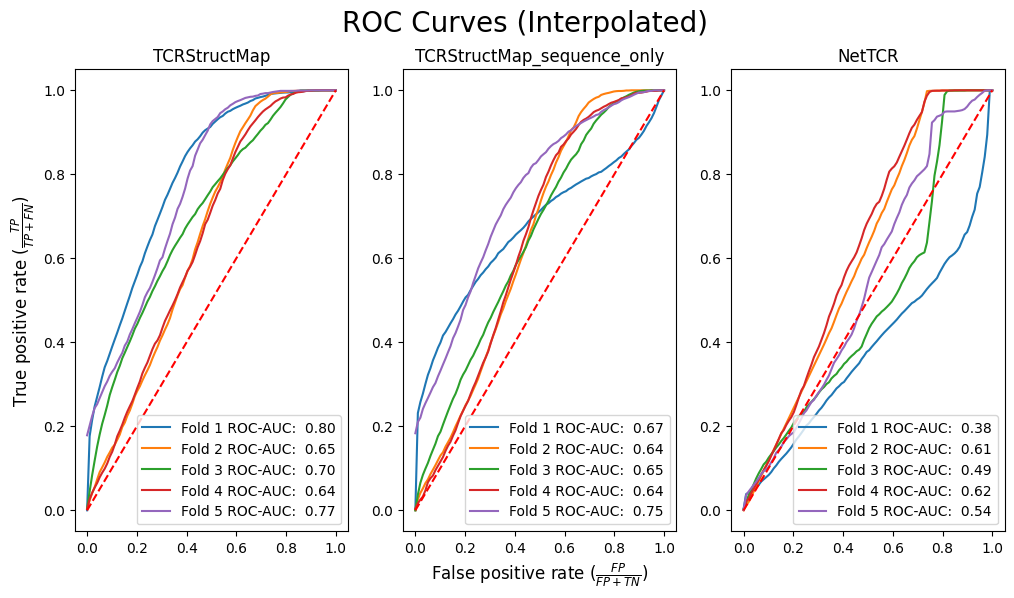

In [15]:
model_groups = roc_results.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('ROC Curves (Interpolated)', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        roc_auc = fold_group['roc_auc'].to_numpy()[0]

        axes[i].plot(fpr_interp, tpr_interp[model_name][fold], label=f'Fold {fold} ROC-AUC: {roc_auc: .2f}')

    if i == 0:
        axes[i].set_ylabel(r'True positive rate ($\frac{TP}{TP + FN}$)', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel(r'False positive rate ($\frac{FP}{FP + TN}$)', fontsize=12)

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [0, 1], 'r--')
    axes[i].legend()

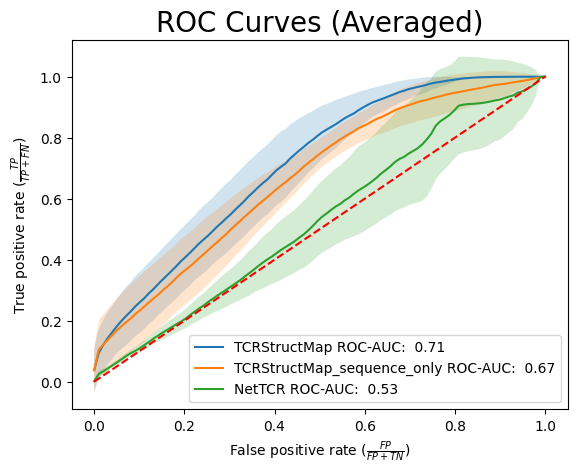

In [16]:
model_groups = roc_results.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

for model_name in model_group_names:
    model_group = model_groups.get_group(model_name)

    tpr_mean = np.mean(np.array(list(tpr_interp[model_name].values())).T, axis=1)
    tpr_std = np.std(np.array(list(tpr_interp[model_name].values())).T, axis=1)

    roc_auc = metrics.auc(fpr_interp, tpr_mean)

    plt.plot(fpr_interp, tpr_mean, label=f'{model_name} ROC-AUC: {roc_auc: .2f}')
    plt.fill_between(fpr_interp, tpr_mean - tpr_std, tpr_mean + tpr_std, alpha=0.2)

plt.title('ROC Curves (Averaged)', fontsize=20)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel(r'False positive rate ($\frac{FP}{FP + TN}$)')
plt.ylabel(r'True positive rate ($\frac{TP}{TP + FN}$)')
plt.legend()

plt.show()

## Precision-Recall

In [17]:
pr_results = predictions.groupby(['model_name', 'fold']).apply(
    lambda group: metrics.precision_recall_curve(group['label'], group['prediction']),
    include_groups=False,
)
pr_results.name = 'pr_curve'
pr_results = pr_results.reset_index()

In [18]:
pr_results[['precision', 'recall', 'threshold']] = pr_results['pr_curve'].apply(pd.Series)

In [19]:
pr_results['pr_auc'] = pr_results.apply(lambda row: metrics.auc(row['recall'], row['precision']), axis=1)

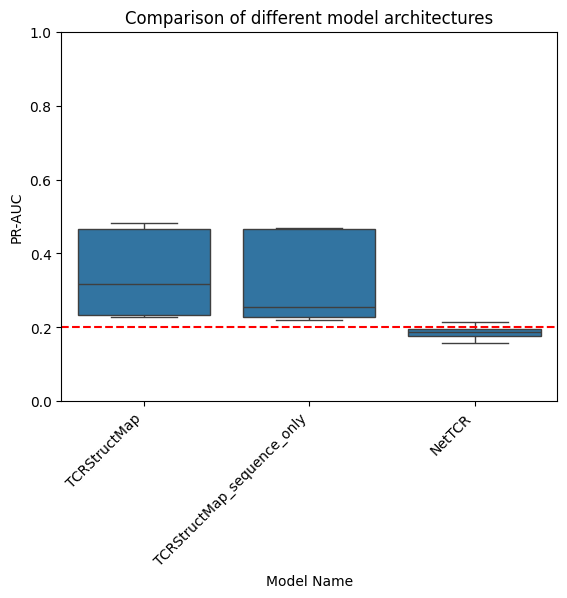

,mean,median,std
model_name,,,
TCRStructMap,0.345571,0.316539,0.122627
TCRStructMap_sequence_only,0.327543,0.256017,0.128773
NetTCR,0.186307,0.188025,0.021207


In [20]:
sns.boxplot(pr_results, x='model_name', y='pr_auc', order=sorted(pr_results['model_name'], key=model_name_sort_key))
plt.axhline(0.2, color='r', linestyle='dashed')

plt.title('Comparison of different model architectures')
plt.ylim([0.0, 1.0])
plt.xlabel('Model Name')
plt.ylabel('PR-AUC')
plt.xticks(rotation=45, ha='right')
plt.show()

pr_results_agg = pr_results.groupby('model_name')['pr_auc'].agg(['mean', 'median', 'std'])
pr_results_agg = pr_results_agg.loc[sorted(pr_results_agg.index, key=model_name_sort_key)]
pr_results_agg

In [21]:
groups = list(pr_results.groupby('model_name')['pr_auc'])
groups = sorted(groups, key=lambda group: model_name_sort_key(group[0]))

print(stats.kruskal(*[group for _, group in groups]))

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.ranksums(group1, group2)

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

KruskalResult(statistic=9.620000000000005, pvalue=0.008147859697679966)


,group1,group2,stat,p_val,signficant
0,TCRStructMap,TCRStructMap_sequence_only,0.731126,0.464702,False
1,TCRStructMap,NetTCR,2.611165,0.009023,True
2,TCRStructMap_sequence_only,NetTCR,2.611165,0.009023,True


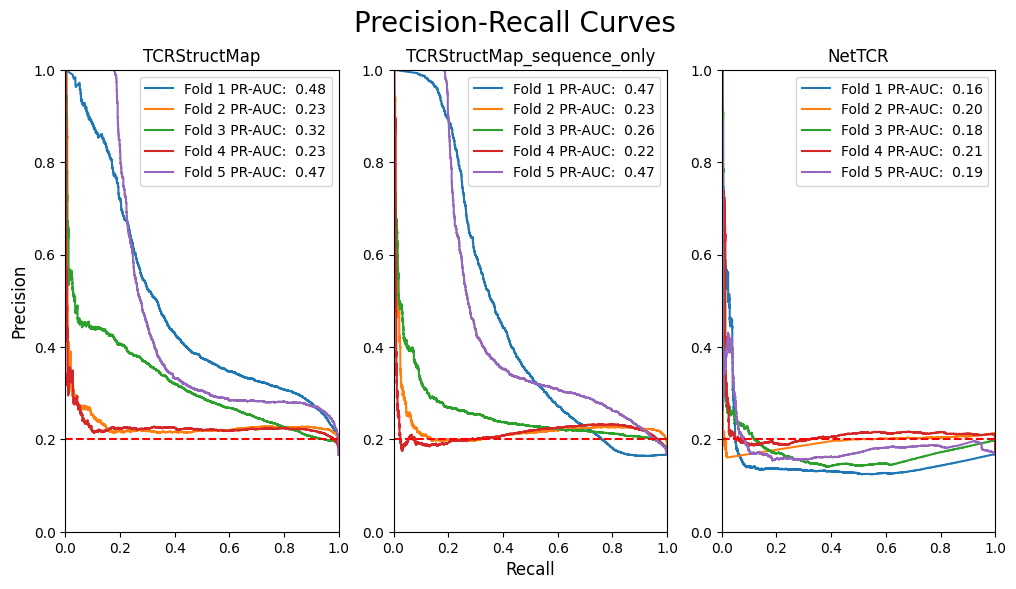

In [22]:
model_groups = pr_results.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('Precision-Recall Curves', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        pr_auc = fold_group['pr_auc'].to_numpy()[0]
        group = fold_group.explode(['recall', 'precision'])

        axes[i].plot(group['recall'], group['precision'], label=f'Fold {fold} PR-AUC: {pr_auc: .2f}')

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [1 / 5, 1 / 5], 'r--')

    if i == 0:
        axes[i].set_ylabel('Precision', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel('Recall', fontsize=12)

    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1])
    axes[i].legend()

In [23]:
model_groups = pr_results.groupby('model_name')

recall_interp = np.linspace(0, 1, 100)
precision_interp = {}

for model_name, model_group in model_groups:
    precision_interp[model_name] = {}
    for fold, fold_group in model_group.groupby('fold'):
        group = fold_group.explode(['recall', 'precision'])

        precision_interp[model_name][fold] = np.interp(
            recall_interp,
            group['recall'].apply(float)[::-1],
            group['precision'].apply(float)[::-1],
        )

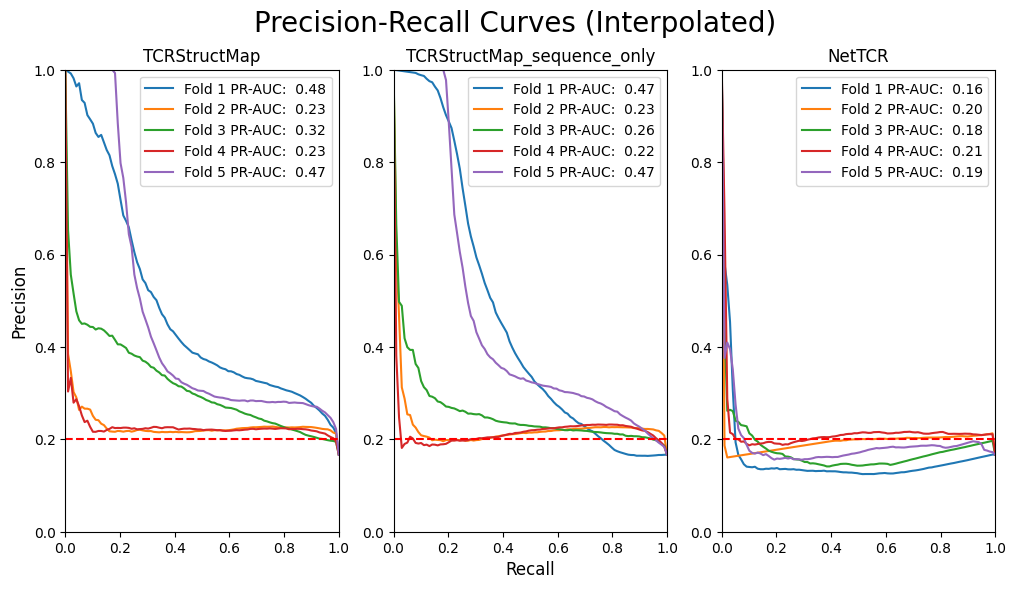

In [24]:
model_groups = pr_results.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('Precision-Recall Curves (Interpolated)', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        pr_auc = fold_group['pr_auc'].to_numpy()[0]

        axes[i].plot(recall_interp, precision_interp[model_name][fold], label=f'Fold {fold} PR-AUC: {pr_auc: .2f}')

    if i == 0:
        axes[i].set_ylabel('Precision', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel('Recall', fontsize=12)

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [1 / 5, 1 / 5], 'r--')
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1])
    axes[i].legend()

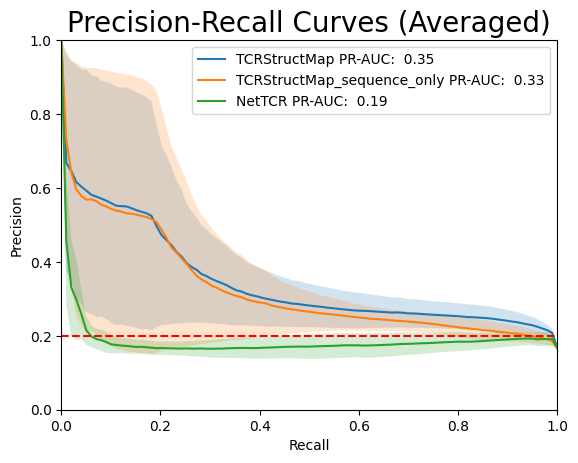

In [25]:
model_groups = pr_results.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

for model_name in model_group_names:
    precision_mean = np.mean(np.array(list(precision_interp[model_name].values())).T, axis=1)
    precision_std = np.std(np.array(list(precision_interp[model_name].values())).T, axis=1)

    pr_auc = metrics.auc(recall_interp, precision_mean)

    plt.plot(recall_interp, precision_mean, label=f'{model_name} PR-AUC: {pr_auc: .2f}')
    plt.fill_between(recall_interp, precision_mean - precision_std, precision_mean + precision_std, alpha=0.2)

plt.title('Precision-Recall Curves (Averaged)', fontsize=20)
plt.plot([0, 1], [1 / 5, 1 / 5], 'r--')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.legend()

plt.show()

### Balancing classes

In [26]:
def down_sample_group(group: pd.DataFrame, random_state: int | np.random.Generator | None = None) -> pd.DataFrame:
    positives = group[group['label'] == 1]
    negatives = group[group['label'] == 0]

    num_positives = len(positives)
    num_negatives = len(negatives)

    if num_positives > num_negatives:
        return pd.concat([positives.sample(num_negatives, random_state=random_state), negatives])

    if num_positives < num_negatives:
        return pd.concat([positives, negatives.sample(num_positives, random_state=random_state)])

    return group


rng = np.random.default_rng(123)
balanced_predictions = (
    predictions.groupby(['model_name', 'fold'])
    .apply(
        down_sample_group,
        random_state=rng,
        include_groups=False,
    )
    .reset_index()
)

In [27]:
pr_results_balanced = balanced_predictions.groupby(['model_name', 'fold']).apply(
    lambda group: metrics.precision_recall_curve(group['label'], group['prediction']),
    include_groups=False,
)
pr_results_balanced.name = 'pr_curve'
pr_results_balanced = pr_results_balanced.reset_index()

In [28]:
pr_results_balanced[['precision', 'recall', 'threshold']] = pr_results_balanced['pr_curve'].apply(pd.Series)

In [29]:
pr_results_balanced['pr_auc'] = pr_results_balanced.apply(
    lambda row: metrics.auc(row['recall'], row['precision']), axis=1
)

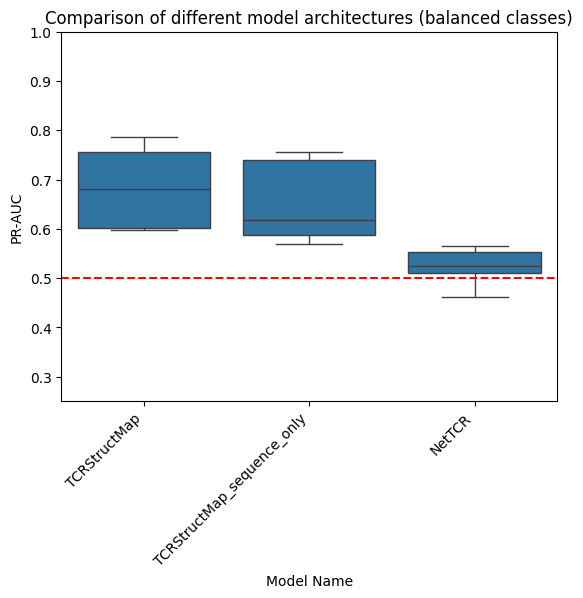

,mean,median,std
model_name,,,
TCRStructMap,0.684545,0.679996,0.086929
TCRStructMap_sequence_only,0.653892,0.617490,0.087891
NetTCR,0.522847,0.523813,0.040699


In [30]:
sns.boxplot(
    pr_results_balanced,
    x='model_name',
    y='pr_auc',
    order=sorted(pr_results_balanced['model_name'].unique(), key=model_name_sort_key),
)
plt.axhline(0.5, color='r', linestyle='dashed')

plt.title('Comparison of different model architectures (balanced classes)')
plt.xlabel('Model Name')
plt.ylabel('PR-AUC')
plt.xticks(rotation=45, ha='right')
plt.ylim([0.25, 1.0])
plt.show()

pr_results_balanced_agg = pr_results_balanced.groupby('model_name')['pr_auc'].agg(['mean', 'median', 'std'])
pr_results_balanced_agg = pr_results_balanced_agg.loc[sorted(pr_results_balanced_agg.index, key=model_name_sort_key)]
pr_results_balanced_agg

In [31]:
groups = list(pr_results_balanced.groupby('model_name')['pr_auc'])
groups = sorted(groups, key=lambda group: model_name_sort_key(group[0]))

print(stats.kruskal(*[group for _, group in groups]))

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.ranksums(group1, group2)

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

KruskalResult(statistic=9.780000000000001, pvalue=0.007521422474993261)


,group1,group2,stat,p_val,signficant
0,TCRStructMap,TCRStructMap_sequence_only,0.940019,0.347208,False
1,TCRStructMap,NetTCR,2.611165,0.009023,True
2,TCRStructMap_sequence_only,NetTCR,2.611165,0.009023,True


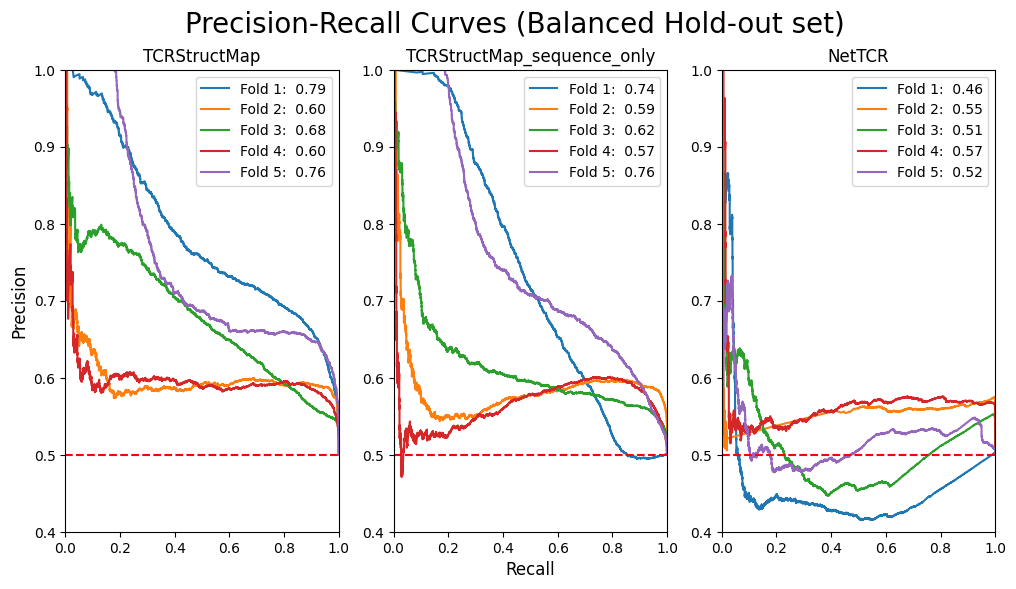

In [32]:
model_groups = pr_results_balanced.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('Precision-Recall Curves (Balanced Hold-out set)', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        roc_auc = fold_group['pr_auc'].to_numpy()[0]
        group = fold_group.explode(['recall', 'precision'])

        axes[i].plot(group['recall'], group['precision'], label=f'Fold {fold}: {roc_auc: .2f}')

    if i == 0:
        axes[i].set_ylabel('Precision', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel('Recall', fontsize=12)

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [0.5, 0.5], 'r--')
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0.4, 1])
    axes[i].legend()

In [33]:
model_groups = pr_results_balanced.groupby('model_name')

recall_interp = np.linspace(0, 1, 100)
precision_interp = {}

for model_name, model_group in model_groups:
    precision_interp[model_name] = {}
    for fold, fold_group in model_group.groupby('fold'):
        group = fold_group.explode(['recall', 'precision'])

        precision_interp[model_name][fold] = np.interp(
            recall_interp,
            group['recall'].apply(float)[::-1],
            group['precision'].apply(float)[::-1],
        )

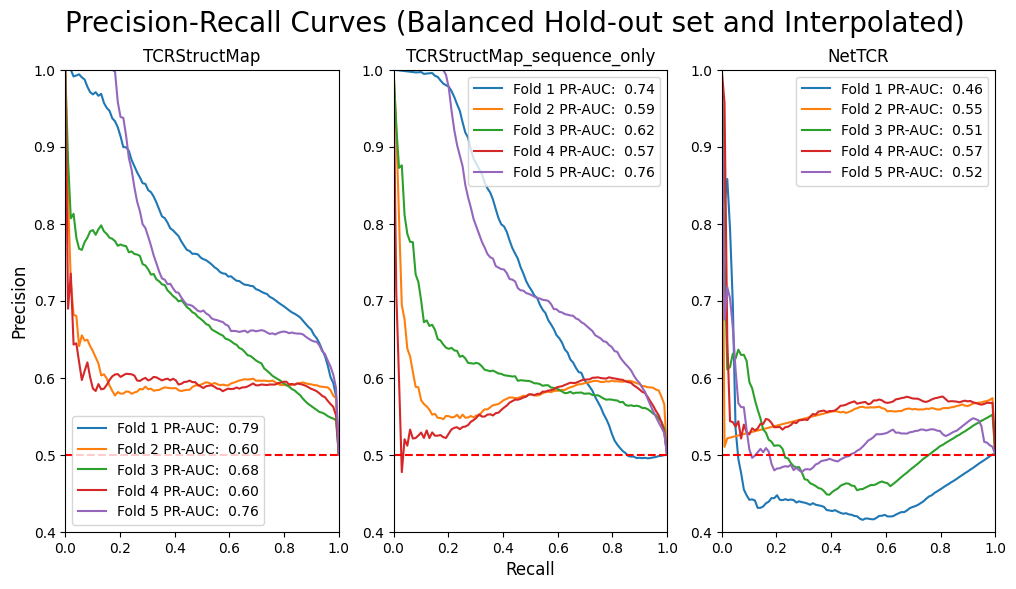

In [34]:
model_groups = pr_results_balanced.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('Precision-Recall Curves (Balanced Hold-out set and Interpolated)', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        pr_auc = fold_group['pr_auc'].to_numpy()[0]

        axes[i].plot(recall_interp, precision_interp[model_name][fold], label=f'Fold {fold} PR-AUC: {pr_auc: .2f}')

    if i == 0:
        axes[i].set_ylabel('Precision', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel('Recall', fontsize=12)

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [0.5, 0.5], 'r--')
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0.4, 1])
    axes[i].legend()

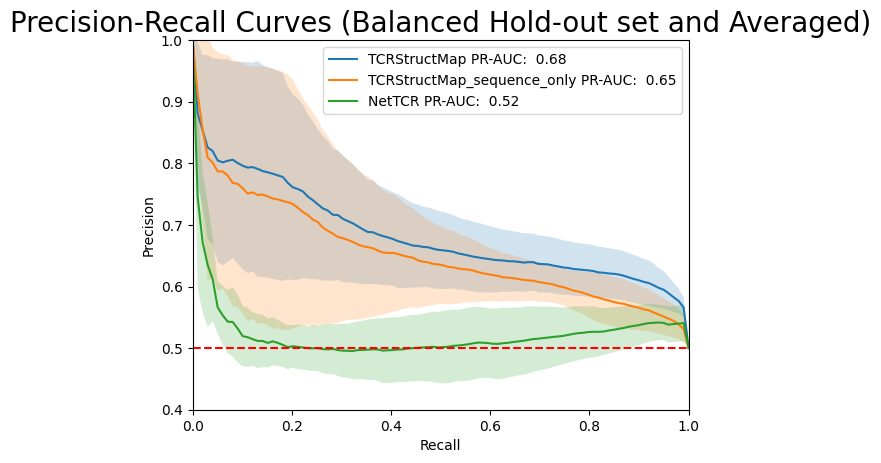

In [35]:
model_groups = pr_results_balanced.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), key=model_name_sort_key)

for model_name in model_group_names:
    precision_mean = np.mean(np.array(list(precision_interp[model_name].values())).T, axis=1)
    precision_std = np.std(np.array(list(precision_interp[model_name].values())).T, axis=1)

    pr_auc = metrics.auc(recall_interp, precision_mean)

    plt.plot(recall_interp, precision_mean, label=f'{model_name} PR-AUC: {pr_auc: .2f}')
    plt.fill_between(recall_interp, precision_mean - precision_std, precision_mean + precision_std, alpha=0.2)

plt.title('Precision-Recall Curves (Balanced Hold-out set and Averaged)', fontsize=20)
plt.plot([0, 1], [0.5, 0.5], 'r--')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.xlim([0, 1])
plt.ylim([0.4, 1])
plt.legend()

plt.show()

## F1-Score

In [36]:
THRESHOLD = 0.5
predictions['prediction_binary'] = (predictions['prediction'] > THRESHOLD).apply(int)

In [37]:
f1_results = predictions.groupby(['model_name', 'fold']).apply(
    lambda row: metrics.f1_score(row['label'], row['prediction_binary']),
    include_groups=False,
)
f1_results.name = 'f1_score'
f1_results = f1_results.reset_index()

f1_results_table = f1_results.pivot_table(index='fold', columns='model_name', values='f1_score')
f1_results_table = f1_results_table[sorted(f1_results_table.columns, key=model_name_sort_key)]
f1_results_table

model_name,TCRStructMap,TCRStructMap_sequence_only,NetTCR
fold,,,
1,0.381910,0.411721,0.035861
2,0.156820,0.164623,0.000000
3,0.228008,0.197531,0.014324
4,0.124459,0.133570,0.015288
5,0.351738,0.352974,0.015544


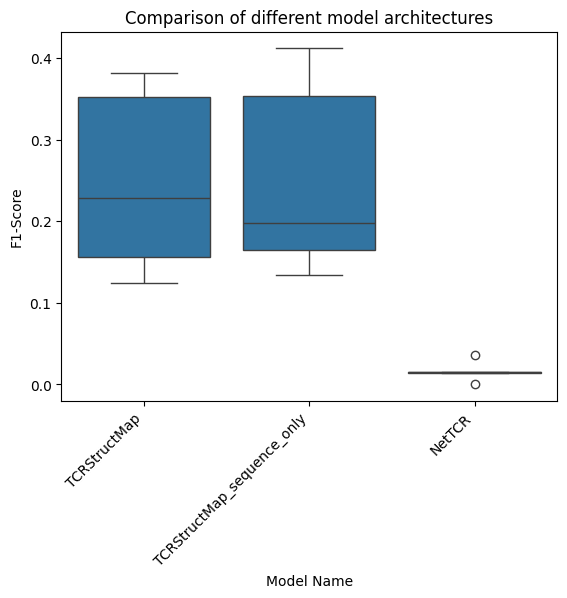

,mean,median,std
model_name,,,
TCRStructMap,0.248587,0.228008,0.114747
TCRStructMap_sequence_only,0.252083,0.197531,0.122815
NetTCR,0.016203,0.015288,0.012785


In [38]:
sns.boxplot(
    f1_results,
    x='model_name',
    y='f1_score',
    order=sorted(f1_results['model_name'].unique(), key=model_name_sort_key),
)

plt.title('Comparison of different model architectures')
plt.xlabel('Model Name')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.show()

f1_results_agg = f1_results.groupby('model_name')['f1_score'].agg(['mean', 'median', 'std'])
f1_results_agg = f1_results_agg.loc[sorted(f1_results_agg.index, key=model_name_sort_key)]
f1_results_agg

In [39]:
groups = list(f1_results.groupby('model_name')['f1_score'])
groups = sorted(groups, key=lambda group: model_name_sort_key(group[0]))

print(stats.kruskal(*[group for _, group in groups]))

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.ranksums(group1, group2)

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

KruskalResult(statistic=9.420000000000009, pvalue=0.00900477758243652)


,group1,group2,stat,p_val,signficant
0,TCRStructMap,TCRStructMap_sequence_only,-0.313340,0.754023,False
1,TCRStructMap,NetTCR,2.611165,0.009023,True
2,TCRStructMap_sequence_only,NetTCR,2.611165,0.009023,True


### Balancing classes

In [40]:
balanced_predictions['prediction_binary'] = (balanced_predictions['prediction'] > THRESHOLD).apply(int)

In [41]:
f1_results_balanced = balanced_predictions.groupby(['model_name', 'fold']).apply(
    lambda row: metrics.f1_score(row['label'], row['prediction_binary']),
    include_groups=False,
)
f1_results_balanced.name = 'f1_score'
f1_results_balanced = f1_results_balanced.reset_index()

f1_results_balanced_table = f1_results_balanced.pivot_table(index='fold', columns='model_name', values='f1_score')
f1_results_balanced_table = f1_results_balanced_table[
    sorted(f1_results_balanced_table.columns, key=model_name_sort_key)
]
f1_results_balanced_table

model_name,TCRStructMap,TCRStructMap_sequence_only,NetTCR
fold,,,
1,0.442652,0.479126,0.036256
2,0.196118,0.224582,0.000000
3,0.259251,0.244862,0.014362
4,0.149301,0.171994,0.015329
5,0.401869,0.419461,0.015693


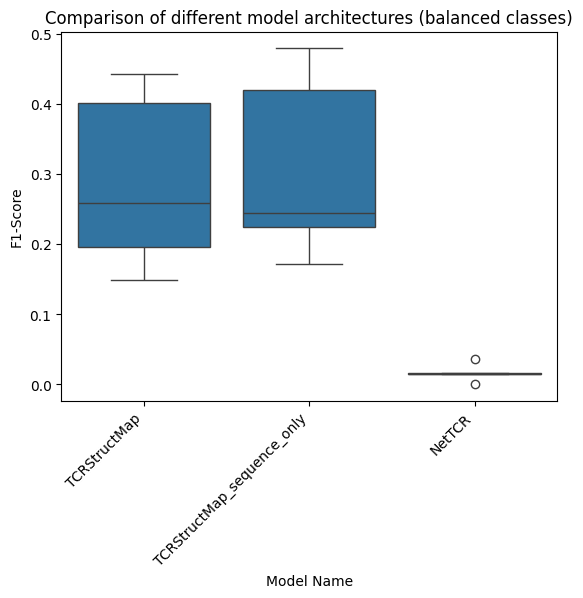

,mean,median,std
model_name,,,
TCRStructMap,0.289838,0.259251,0.127840
TCRStructMap_sequence_only,0.308005,0.244862,0.133370
NetTCR,0.016328,0.015329,0.012932


In [42]:
sns.boxplot(
    f1_results_balanced,
    x='model_name',
    y='f1_score',
    order=sorted(f1_results_balanced['model_name'].unique(), key=model_name_sort_key),
)

plt.title('Comparison of different model architectures (balanced classes)')
plt.xlabel('Model Name')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.show()

f1_results_balanced_agg = f1_results_balanced.groupby('model_name')['f1_score'].agg(['mean', 'median', 'std'])
f1_results_balanced_agg = f1_results_balanced_agg.loc[sorted(f1_results_balanced_agg.index, key=model_name_sort_key)]
f1_results_balanced_agg

In [43]:
groups = list(f1_results_balanced.groupby('model_name')['f1_score'])
groups = sorted(groups, key=lambda group: model_name_sort_key(group[0]))

print(stats.kruskal(*[group for _, group in groups]))

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.ranksums(group1, group2)

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

KruskalResult(statistic=9.420000000000009, pvalue=0.00900477758243652)


,group1,group2,stat,p_val,signficant
0,TCRStructMap,TCRStructMap_sequence_only,-0.313340,0.754023,False
1,TCRStructMap,NetTCR,2.611165,0.009023,True
2,TCRStructMap_sequence_only,NetTCR,2.611165,0.009023,True


## Comparison of prediction results to mimimum distance between the peptides and the training set

In [44]:
amino_acid_olcs = np.array(sorted(IUPACData.protein_letters_3to1.values()))
amino_acid_olcs

array(['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P',
       'Q', 'R', 'S', 'T', 'V', 'W', 'Y'], dtype='<U1')

In [45]:
peptides_aa = np.array(
    [
        ''.join([amino_acid_olcs[one_hot.astype(bool)][0] for one_hot in peptide if np.sum(one_hot) > 0])
        for peptide in peptides
    ]
)

In [46]:
predictions['peptide_sequence'] = predictions['index'].map(lambda idx: peptides_aa[idx])

In [47]:
with open('data/interim/peptides.txt') as fh:
    peptide_key = np.array(fh.read().rstrip().split('\n'))

peptide_distances = np.loadtxt('data/interim/peptide_distances.txt', dtype=int)

In [48]:
# TODO think about how to handle peptides that have been cropped...


def get_minimum_peptide_distance(peptide_sequence: str, training_peptides: np.ndarray) -> int:
    if peptide_sequence not in peptide_key:
        return np.nan

    training_key_idxs = np.where(np.isin(peptide_key, training_peptides))[0]
    peptide_index = np.where(peptide_sequence == peptide_key)[0][0]

    return np.min(peptide_distances[peptide_index][training_key_idxs])

In [49]:
peptide_folds = predictions[['peptide_sequence', 'fold', 'model_name']].drop_duplicates()
peptide_folds['min_peptide_distance'] = peptide_folds.apply(
    lambda row: get_minimum_peptide_distance(
        row.peptide_sequence,
        peptides_aa[folds_nettcr != row.fold] if row.model_name == 'NetTCR' else peptides_aa[folds != row.fold],
    ),
    axis=1,
)

In [50]:
predictions = predictions.merge(peptide_folds, how='left', on=['peptide_sequence', 'fold', 'model_name'])

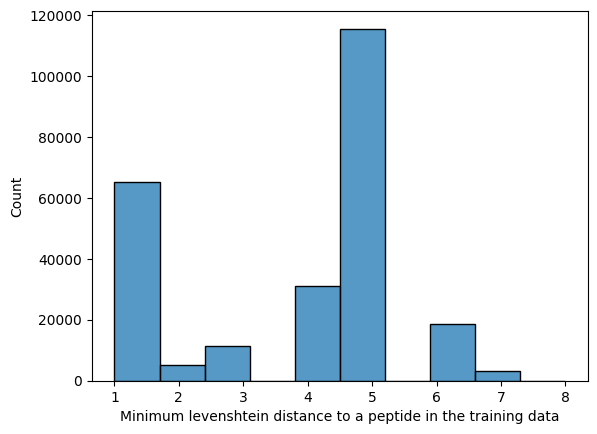

In [51]:
sns.histplot(predictions, x='min_peptide_distance', bins=10)

plt.xlabel('Minimum levenshtein distance to a peptide in the training data')
plt.show()

In [52]:
peptide_distance_roc_aucs = predictions.groupby(['model_name', 'fold', 'min_peptide_distance']).apply(
    lambda group: metrics.roc_auc_score(group['label'], group['prediction']),
    include_groups=False,
)
peptide_distance_roc_aucs.name = 'roc_auc'

peptide_distance_roc_aucs = peptide_distance_roc_aucs.reset_index()

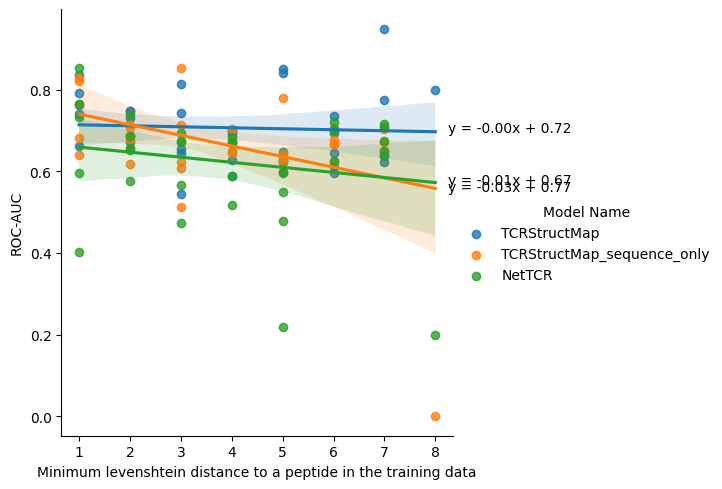

In [53]:
ax = sns.lmplot(
    peptide_distance_roc_aucs,
    x='min_peptide_distance',
    y='roc_auc',
    hue='model_name',
    hue_order=sorted(peptide_distance_roc_aucs['model_name'].unique(), key=model_name_sort_key),
)

for model_name in peptide_distance_roc_aucs['model_name'].unique():
    subset = peptide_distance_roc_aucs[peptide_distance_roc_aucs['model_name'] == model_name]
    slope, intercept, r_value, p_value, std_err = stats.linregress(subset['min_peptide_distance'], subset['roc_auc'])

    equation = f'y = {slope:.2f}x + {intercept:.2f}'

    x_pos = subset['min_peptide_distance'].max() + 0.25
    y_pos = slope * x_pos + intercept

    plt.text(x_pos, y_pos, equation, color='black')

ax.legend.set_title('Model Name')
plt.xlabel('Minimum levenshtein distance to a peptide in the training data')
plt.ylabel('ROC-AUC')

plt.show()

In [54]:
peptide_distance_roc_aucs_lines = peptide_distance_roc_aucs.groupby(['model_name', 'fold']).apply(
    lambda group: stats.linregress(group['min_peptide_distance'], group['roc_auc']),
    include_groups=False,
)

peptide_distance_roc_aucs_lines.name = 'line'
peptide_distance_roc_aucs_lines = peptide_distance_roc_aucs_lines.reset_index()

peptide_distance_roc_aucs_lines[['slope', 'intercept', 'r_value', 'p_value', 'std_err']] = (
    peptide_distance_roc_aucs_lines['line'].apply(pd.Series)
)

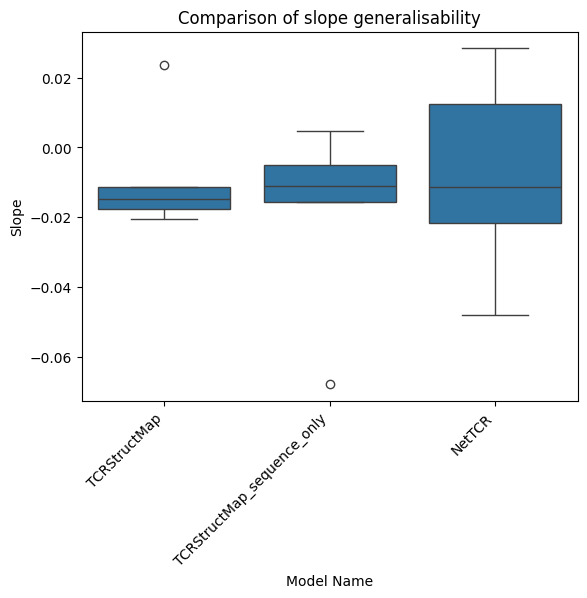

,mean,median,std
model_name,,,
TCRStructMap,-0.008160,-0.014859,0.018046
TCRStructMap_sequence_only,-0.018994,-0.011103,0.028381
NetTCR,-0.007999,-0.011204,0.029697


In [55]:
sns.boxplot(
    peptide_distance_roc_aucs_lines,
    x='model_name',
    y='slope',
    order=sorted(peptide_distance_roc_aucs_lines['model_name'].unique(), key=model_name_sort_key),
)

plt.title('Comparison of slope generalisability')
plt.ylabel('Slope')
plt.xlabel('Model Name')
plt.xticks(rotation=45, ha='right')
plt.show()

peptide_distance_roc_aucs_lines_agg = peptide_distance_roc_aucs_lines.groupby('model_name')['slope'].agg(
    ['mean', 'median', 'std'],
)
peptide_distance_roc_aucs_lines_agg = peptide_distance_roc_aucs_lines_agg.loc[
    sorted(peptide_distance_roc_aucs_lines_agg.index, key=model_name_sort_key)
]
peptide_distance_roc_aucs_lines_agg

In [56]:
groups = list(peptide_distance_roc_aucs_lines.groupby('model_name')['slope'])

print(stats.kruskal(*[group for _, group in groups]))

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.ranksums(group1, group2)

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

KruskalResult(statistic=0.0800000000000054, pvalue=0.9607894391523206)


,group1,group2,stat,p_val,signficant
0,NetTCR,TCRStructMap,0.104447,0.916815,False
1,NetTCR,TCRStructMap_sequence_only,0.313340,0.754023,False
2,TCRStructMap,TCRStructMap_sequence_only,-0.313340,0.754023,False


Removing outlier to see the effect...

In [57]:
peptide_distance_roc_aucs.sort_values('roc_auc')

,model_name,fold,min_peptide_distance,roc_auc
105,TCRStructMap_sequence_only,5,8.0,0.000000
35,NetTCR,5,8.0,0.200000
4,NetTCR,1,5.0,0.218585
14,NetTCR,3,1.0,0.401663
9,NetTCR,2,3.0,0.472740
...,...,...,...,...
40,TCRStructMap,1,5.0,0.840847
67,TCRStructMap,5,5.0,0.850944
21,NetTCR,4,1.0,0.853500
80,TCRStructMap_sequence_only,2,3.0,0.854438


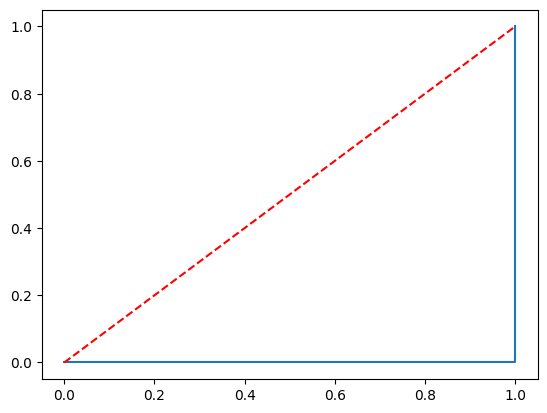

In [58]:
worst_fold = predictions.query(
    "model_name == 'TCRStructMap_sequence_only' and fold == 5 and min_peptide_distance == 8.0"
)
fpr, tpr, thresholds = metrics.roc_curve(worst_fold['label'], worst_fold['prediction'])

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], 'r--')

plt.show()

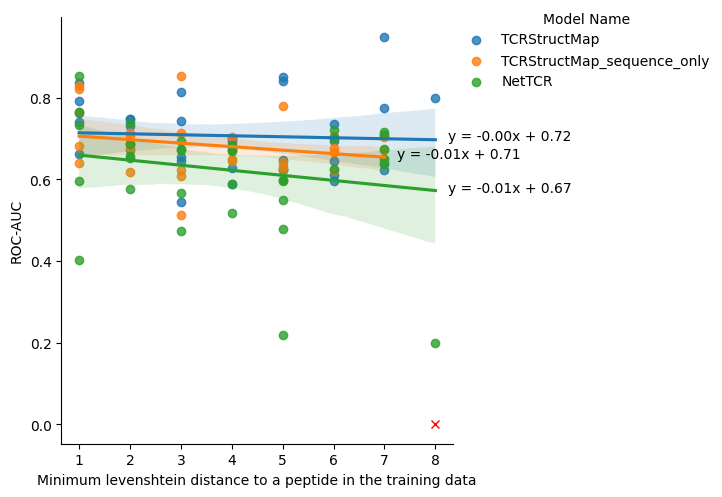

In [59]:
peptide_distance_roc_aucs_remove_outlier = peptide_distance_roc_aucs.query(
    "not (model_name == 'TCRStructMap_sequence_only' and fold == 5 and min_peptide_distance == 8.0)"
)

peptide_distance_roc_aucs_outlier = peptide_distance_roc_aucs.query(
    "model_name == 'TCRStructMap_sequence_only' and fold == 5 and min_peptide_distance == 8.0"
)

ax = sns.lmplot(
    peptide_distance_roc_aucs_remove_outlier,
    x='min_peptide_distance',
    y='roc_auc',
    hue='model_name',
    hue_order=sorted(peptide_distance_roc_aucs_remove_outlier['model_name'].unique(), key=model_name_sort_key),
)

for model_name in peptide_distance_roc_aucs_remove_outlier['model_name'].unique():
    subset = peptide_distance_roc_aucs_remove_outlier[
        peptide_distance_roc_aucs_remove_outlier['model_name'] == model_name
    ]
    slope, intercept, r_value, p_value, std_err = stats.linregress(subset['min_peptide_distance'], subset['roc_auc'])

    equation = f'y = {slope:.2f}x + {intercept:.2f}'

    x_pos = subset['min_peptide_distance'].max() + 0.25
    y_pos = slope * x_pos + intercept

    plt.text(x_pos, y_pos, equation, color='black')

plt.plot(peptide_distance_roc_aucs_outlier['min_peptide_distance'], peptide_distance_roc_aucs_outlier['roc_auc'], 'rx')

ax.legend.set_title('Model Name')
sns.move_legend(ax, 'upper right')
plt.xlabel('Minimum levenshtein distance to a peptide in the training data')
plt.ylabel('ROC-AUC')

plt.show()

In [60]:
peptide_distance_roc_aucs_remove_outlier_lines = peptide_distance_roc_aucs_remove_outlier.groupby(
    ['model_name', 'fold'],
).apply(
    lambda group: stats.linregress(group['min_peptide_distance'], group['roc_auc']),
    include_groups=False,
)

peptide_distance_roc_aucs_remove_outlier_lines.name = 'line'
peptide_distance_roc_aucs_remove_outlier_lines = peptide_distance_roc_aucs_remove_outlier_lines.reset_index()

peptide_distance_roc_aucs_remove_outlier_lines[['slope', 'intercept', 'r_value', 'p_value', 'std_err']] = (
    peptide_distance_roc_aucs_remove_outlier_lines['line'].apply(pd.Series)
)

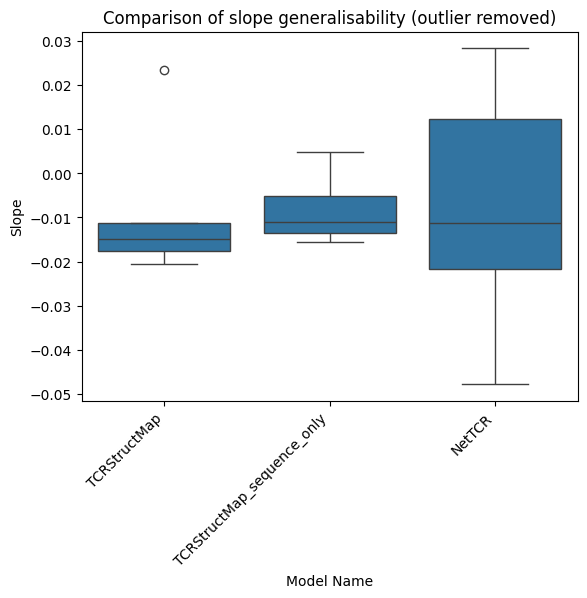

,mean,median,std
model_name,,,
TCRStructMap,-0.008160,-0.014859,0.018046
TCRStructMap_sequence_only,-0.008123,-0.011103,0.008196
NetTCR,-0.007999,-0.011204,0.029697


In [61]:
sns.boxplot(
    peptide_distance_roc_aucs_remove_outlier_lines,
    x='model_name',
    y='slope',
    order=sorted(peptide_distance_roc_aucs_remove_outlier_lines['model_name'].unique(), key=model_name_sort_key),
)

plt.title('Comparison of slope generalisability (outlier removed)')
plt.xlabel('Model Name')
plt.ylabel('Slope')
plt.xticks(rotation=45, ha='right')
plt.show()

peptide_distance_roc_aucs_remove_outlier_lines_agg = peptide_distance_roc_aucs_remove_outlier_lines.groupby(
    'model_name'
)['slope'].agg(['mean', 'median', 'std'])
peptide_distance_roc_aucs_remove_outlier_lines_agg = peptide_distance_roc_aucs_remove_outlier_lines_agg.loc[
    sorted(peptide_distance_roc_aucs_remove_outlier_lines_agg.index, key=model_name_sort_key)
]
peptide_distance_roc_aucs_remove_outlier_lines_agg

In [62]:
groups = list(peptide_distance_roc_aucs_remove_outlier_lines.groupby('model_name')['slope'])
groups = sorted(groups, key=lambda group: model_name_sort_key(group[0]))

print(stats.kruskal(*[group for _, group in groups]))

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.ranksums(group1, group2)

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

KruskalResult(statistic=0.5, pvalue=0.7788007830714049)


,group1,group2,stat,p_val,signficant
0,TCRStructMap,TCRStructMap_sequence_only,-0.940019,0.347208,False
1,TCRStructMap,NetTCR,-0.104447,0.916815,False
2,TCRStructMap_sequence_only,NetTCR,0.104447,0.916815,False
